In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import math
import random
import seaborn as sns
import matplotlib.pyplot as plt
# Sirve para medir la velocidad de una función
import time
%load_ext line_profiler



## Versión 1 (Incorrecta)

In [2]:
# Función que sirve para pasar a ceros y unos los votos

def base_ceros_unos(df):
    df_prueba=df[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]]
    # Agrupamos por distrito
    df_prueba_agg_dist=df_prueba.groupby(['DISTRITO']).sum().reset_index()
    # Hacemos melt a los datos
    df_pob_melt=pd.melt(df_prueba_agg_dist, id_vars=["DISTRITO"], value_vars=["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]).sort_values(by=["DISTRITO"])

    # Data frame con todos los datos desglosados
    df_melt_aux=df_pob_melt.loc[df_pob_melt.index.repeat(df_pob_melt.pop('value'))].set_index('DISTRITO')

    # Hacemos el dataframe de unos y ceros de los votos con el distrito
    df_votos_des=df_melt_aux.variable.str.get_dummies().reset_index()
    df_votos_des

### Comparación de los pesos bootstrap

In [ ]:
# Votos por candidato en la muestra
n_votos_cand=df_stra_sam.sum(0)

# Con las siguientes dos líneas de código se puede replicar el vector de la distribución Dirichlet utilizando solo los pesos (1,1,1,1,...,1)
# en vez de sumar los valores
# Para sumar los valores
valores=np.concatenate((np.zeros(1),np.cumsum(n_votos_cand.astype(int))[:-1])).astype(int)
vector_pesos=np.add.reduceat(np.random.dirichlet(np.ones(int(n_votos_cand.sum())), 1000), valores, axis=1)

# Los pesos de la distribución Dirichlet (método sumando los valores para los parámetros de la Dirichlet)
pesos_bootstrap=np.random.dirichlet(n_votos_cand, 1000)
vector_pesos

array([[0.00463841, 0.6190163 , 0.09659287, ..., 0.00096478, 0.00391333,
        0.18858336],
       [0.00470758, 0.62083457, 0.0950054 , ..., 0.0009018 , 0.00391519,
        0.18755404],
       [0.0046594 , 0.62132282, 0.09547032, ..., 0.00087891, 0.00393293,
        0.18749898],
       ...,
       [0.00477867, 0.62151989, 0.0963781 , ..., 0.00099319, 0.00392132,
        0.18662066],
       [0.00464167, 0.62052543, 0.09609062, ..., 0.00093975, 0.00378752,
        0.1874942 ],
       [0.00487031, 0.61930629, 0.09653734, ..., 0.00096084, 0.00387966,
        0.18810596]])

In [ ]:
pd.DataFrame(vector_pesos).describe()

,0,1,2,3,4,5,6,7
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.004672,0.620438,0.096142,0.079896,0.006570,0.000950,0.003896,0.187436
std,0.000085,0.000597,0.000376,0.000339,0.000095,0.000038,0.000076,0.000457
min,0.004393,0.618276,0.094932,0.078810,0.006307,0.000830,0.003648,0.185849
25%,0.004615,0.620044,0.095887,0.079663,0.006506,0.000924,0.003844,0.187139
50%,0.004673,0.620444,0.096143,0.079893,0.006566,0.000950,0.003898,0.187435
75%,0.004730,0.620831,0.096386,0.080113,0.006634,0.000976,0.003947,0.187751
max,0.004943,0.622356,0.097371,0.080993,0.006849,0.001072,0.004187,0.188952


In [ ]:
pd.DataFrame(pesos_bootstrap).describe()

,0,1,2,3,4,5,6,7
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.004669,0.620444,0.096133,0.079916,0.006559,0.000951,0.003898,0.187429
std,0.000082,0.000601,0.000366,0.000334,0.000099,0.000039,0.000074,0.000495
min,0.004419,0.618586,0.095057,0.078943,0.006243,0.000825,0.003663,0.185715
25%,0.004615,0.620027,0.095883,0.079692,0.006497,0.000926,0.003845,0.187084
50%,0.004666,0.620453,0.096134,0.079919,0.006560,0.000950,0.003902,0.187420
75%,0.004728,0.620849,0.096370,0.080139,0.006624,0.000977,0.003946,0.187764
max,0.004922,0.622206,0.097236,0.080941,0.006851,0.001087,0.004145,0.188766


## Boostrap por votos (borrador)

In [ ]:
# Número total de votos
n_votos=int(df_act_yuc_i[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

df_stra_sam = df_act_yuc_i.sample(n=250, frac=None)

df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

# Votos por candidato en la muestra
n_votos_cand=df_stra_sam.sum(0)

# Los pesos de la distribución Dirichlet
pesos_bootstrap=np.random.dirichlet(n_votos_cand, 1000)

# Data frame con los resultados
df_prop_list=[]

for j in range(1000):
    #print(X_test.shape[0])
    #rng_2 = np.random.default_rng(j)

    # Guardamos la semilla para que el código se reproducible
    rng_2 = np.random.default_rng()
    # La casilla seleccionada por el bootstrap

    # Para completar toda la población
    #cas_sel_boot=rng_2.choice(a=pesos_bootstrap.shape[1],  size=n_votos-int(df_stra_sam.sum()),  p=pesos_bootstrap[j])

    cas_sel_boot=rng_2.choice(a=pesos_bootstrap.shape[1],  size=2000,  p=pesos_bootstrap[j])

    # Total de votos de la muestra simulada
    votos_sim=np.bincount(cas_sel_boot)

    # La estimación puntual
    #array_prop_i=(votos_sim+n_votos_cand)/(votos_sim+n_votos_cand).sum()

    array_prop_i=(votos_sim)/(votos_sim).sum()

    df_prop_list.append(array_prop_i)

array_res=np.array(df_prop_list)

# Los valores de los intervalos de probabilidad lower y upper
inter_prob=np.concatenate((np.apply_along_axis(inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(inter_prob_u, axis=0, arr=array_res)))

# Estimaciones puntuales
est_puntual=array_res.mean(0)


In [ ]:
df_stra_sam["TOTAL"].describe()

count    250.000000
mean     418.048000
std       95.349819
min        1.000000
25%      361.750000
50%      417.500000
75%      475.750000
max      668.000000
Name: TOTAL, dtype: float64

In [ ]:
cas_sel_boot

array([0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 4, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0])

In [ ]:
inter_prob

array([0.4945   , 0.3999875, 0.0254875, 0.003    , 0.0154875, 0.5400125,
       0.444    , 0.04     , 0.0095   , 0.0285   ])

In [ ]:
prop_reales

JOAQUIN_DIAZ_MENA              0.515125
RENAN_BARRERA_CONCHA           0.421366
VIDA_ARAVARI_GOMEZ_HERRERA     0.036792
YAMIL_JASMIN_LOPEZ_MANRIQUE    0.005249
VOTOS_NULOS_CAND_NO_REGIS      0.021467
dtype: float64

In [ ]:
pesos_bootstrap

array([[0.51769551, 0.42180402, 0.03286155, 0.00587692, 0.021762  ],
       [0.51937495, 0.41944502, 0.03342985, 0.00615684, 0.02159334],
       [0.51775865, 0.42206225, 0.03272716, 0.0059806 , 0.02147133],
       ...,
       [0.51961355, 0.42047769, 0.03176489, 0.00592694, 0.02221692],
       [0.51764763, 0.42160687, 0.0331838 , 0.00617267, 0.02138903],
       [0.51771538, 0.42145491, 0.03200406, 0.00614059, 0.02268505]])

In [ ]:
%load_ext line_profiler
%lprun -f prueba prueba(df_act_yuc_i)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


UsageError: Could not find module prueba.
NameError: name 'prueba' is not defined


## Boostrap por votos (sin estratificar)

In [ ]:
def bootstrap_votos_simple(df, num_boot: int=1000, n_sample=None, frac=None):

    est_punt_list=[]

    inter_list=[]

    # Número total de votos
    n_votos=int(df[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]].sum().sum())

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng(20)

    # Vector de pesos de la distribución Dirichlet
    #pesos_bootstrap=rng.dirichlet(np.ones(math.ceil(df.shape[0]*porcentaje)), num_boot)
    #pesos_bootstrap=np.random.dirichlet(np.ones(math.ceil(df.shape[0]*porcentaje_tam)), num_boot)

    for i in range(num_boot):

        df_stra_sam = df_act_yuc_i.sample(n=n_sample, frac=frac)

        df_stra_sam=np.array(df_stra_sam[["JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Votos por candidato en la muestra
        n_votos_cand=df_stra_sam.sum(0)

        # Los pesos de la distribución Dirichlet
        pesos_bootstrap=np.random.dirichlet(n_votos_cand, 1000)

        # Data frame con los resultados
        df_prop_list=[]
        
        for j in range(1000):

            # Guardamos la semilla para que el código se reproducible
            rng_2 = np.random.default_rng()
            # La casilla seleccionada por el bootstrap

            # Para completar toda la población
            #cas_sel_boot=rng_2.choice(a=pesos_bootstrap.shape[1],  size=n_votos-int(df_stra_sam.sum()),  p=pesos_bootstrap[j])

            cas_sel_boot=rng_2.choice(a=pesos_bootstrap.shape[1],  size=3000,  p=pesos_bootstrap[j])

            # Total de votos de la muestra simulada
            votos_sim=np.bincount(cas_sel_boot)

            # La estimación puntual
            #array_prop_i=(votos_sim+n_votos_cand)/(votos_sim+n_votos_cand).sum()

            array_prop_i=(votos_sim)/(votos_sim).sum()

            df_prop_list.append(array_prop_i)

        array_res=np.array(df_prop_list)

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(inter_prob_u, axis=0, arr=array_res)))
        
        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)
        #print(i)
        
    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)

    return array_inter_prob,array_est_punt


In [ ]:
# Tamaño de la muestra
tama_muestra=250
inter_prob_v, est_punt_v=bootstrap_votos_simple(df_act_yuc_i, num_boot=200, n_sample=tama_muestra)

250


In [ ]:
# Guardamos las bases
df_metr_boot_v, df_error_max_v, df_can_cob_v = metricas_bootstrap(prop_reales, inter_prob_v, est_punt_v, porcenta_tama=tama_muestra)

In [ ]:
df_can_cob_v

,Candidato,Numero_total_cob,Cobertura,Porcenta_tama
0,JOAQUIN_DIAZ_MENA,195,0.975,250
1,RENAN_BARRERA_CONCHA,195,0.975,250
2,VIDA_ARAVARI_GOMEZ_HERRERA,200,1.000,250
3,VOTOS_NULOS_CAND_NO_REGIS,200,1.000,250
4,YAMIL_JASMIN_LOPEZ_MANRIQUE,200,1.000,250


In [ ]:
# Candidato con intervalo más largo
df_inter_lar_v=df_metr_boot_v.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v["Porcenta_tama"]=tama_muestra
candidato_mas_largo_v=df_inter_lar_v[df_inter_lar_v["Longitud_intervalo"]==df_inter_lar_v["Longitud_intervalo"].max()]["Candidato"].values[0]

In [ ]:
# Candidato con menor cobertura
candidato_cober_men_v=df_can_cob_v[df_can_cob_v["Cobertura"]==df_can_cob_v["Cobertura"].min()]["Candidato"].values[0]

In [ ]:
df_error_max_v.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,200.000000,200.000000,200.0
mean,100.500000,0.007389,250.0
std,57.879185,0.004944,0.0
min,1.000000,0.000760,250.0
2.5%,5.975000,0.001309,250.0
50%,100.500000,0.006205,250.0
97.5%,195.025000,0.018338,250.0
max,200.000000,0.025809,250.0


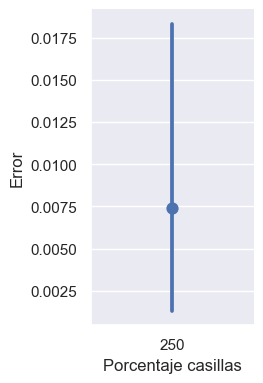

In [ ]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [ ]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v=df_metr_boot_v.drop(columns="Cobertura").merge(df_can_cob_v[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.511000,0.546000,0.035000,0.528242,0.515125,JOAQUIN_DIAZ_MENA,0.013117,250,0.975
1,2,0.507983,0.543333,0.035350,0.525966,0.515125,JOAQUIN_DIAZ_MENA,0.010840,250,0.975
2,3,0.501325,0.537333,0.036008,0.519570,0.515125,JOAQUIN_DIAZ_MENA,0.004445,250,0.975
3,4,0.492325,0.527667,0.035342,0.510816,0.515125,JOAQUIN_DIAZ_MENA,0.004310,250,0.975
4,5,0.489333,0.524667,0.035333,0.506847,0.515125,JOAQUIN_DIAZ_MENA,0.008279,250,0.975
...,...,...,...,...,...,...,...,...,...,...
995,196,0.016333,0.026667,0.010333,0.021575,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000108,250,1.000
996,197,0.018667,0.030000,0.011333,0.023897,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.002430,250,1.000
997,198,0.016000,0.026333,0.010333,0.021090,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000377,250,1.000
998,199,0.015992,0.026333,0.010342,0.021144,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000323,250,1.000


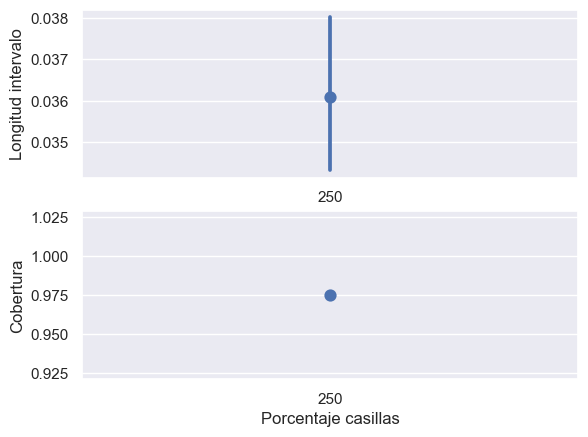

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_mas_largo_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


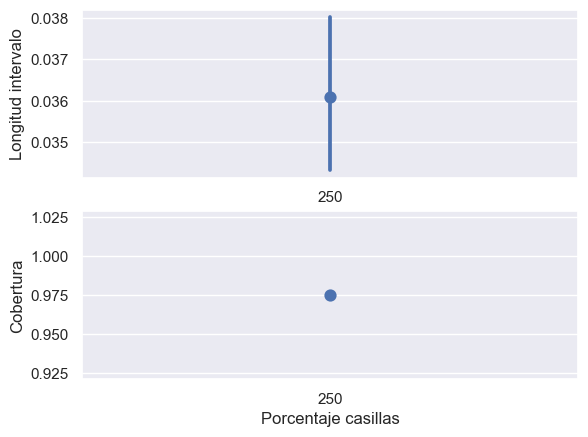

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v[df_metr_boot_c_v["Candidato"]==candidato_cober_men_v].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

In [ ]:
%load_ext line_profiler
%lprun -f boot_estratificado boot_estratificado(df_act_yuc_i, num_boot=20, n_sample=250)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
250


Timer unit: 1e-09 s

Total time: 12.1978 s
File: /var/folders/jr/f7xjgzh56h75snyd84nvhbdc0000gn/T/ipykernel_3741/766673327.py
Function: boot_estratificado at line 2

Line #      Hits         Time  Per Hit   % Time  Line Contents
     2                                           def boot_estratificado(df_act_yuc_i, num_boot: int=1000, n_sample=None, frac=None):
     3                                           
     4                                               # Listas auxiliares para guardar los datos
     5         1       2000.0   2000.0      0.0      est_punt_list=[]
     6                                           
     7         1          0.0      0.0      0.0      inter_list=[]
     8                                           
     9                                               # Cuantas casillas hay por distrito en toda la base
    10         1    1826000.0    2e+06      0.0      array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())
    11             

## Boostrap por votos estratificado (borrador)

In [ ]:
n_sample=250

num_boot=10

# Listas auxiliares para guardar los datos
est_punt_list=[]

inter_list=[]

# Cuantas casillas hay por distrito en toda la base
array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())


# Número de poblaciones
n_boot=1000

# Tamaño de la población (la muestra)
t_p=2000

# Semilla para las muestras de la Dirichlet
rng = np.random.default_rng()

# Hacemos el muestreo estratificado
if n_sample==None:
    # Hacemos el muestreo de frac de las casilas estratificado por distrito
    X_train, df_stra_sam = train_test_split(df_act_yuc_i[["DISTRITO","ID CASILLA","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS","TOTAL"]], stratify=df_act_yuc_i['DISTRITO'], test_size=frac)
else:
    # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
    df_stra_sam=muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, seed=None)

# Guardamos en un numpy array el dataframe de la muestra
array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

# Hacemos la suma agrupando por distritos
#valores_votos_dist=[np.insert(array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), 0, val) for val in val_dist]

valores_votos_dist=[array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int) for val in val_dist]

# Separamos todos los distritos en distintos arrays
valores_sep_est=[array_muest[array_muest[:,0]==val] for val in val_dist]

# Los porcentajes de cada distrito en la muestra
array_pesos_normalizados_dist=np.array(df_stra_sam["DISTRITO"].value_counts(normalize=True).sort_index())

# Obtenemos los totales de las proporciones para cada estrato (distrito)
totales_prop_est=obtener_totales(array_pesos_normalizados_dist, t_p)

# Cuantas casillas hay por distrito en la muestra
array_frec_est_mue=np.array(df_stra_sam["DISTRITO"].value_counts().sort_index())

# Vector de pesos de la distribución Dirichlet
vectores_dir=[f_a(xi,n_boot) for xi in valores_votos_dist]

# Calculamos el tamaño del vector de candidatos
tam_vect=array_muest.shape[1]-1

# Índices de la base por distritos
#array_index_est=np.array(df_stra_sam.reset_index().groupby('DISTRITO')['index'].apply(list))

#pesos_bootstrap=np.random.dirichlet(np.ones(df_stra_sam.shape[0], len(df_stra_sam["DISTRITO"].sort_values().unique())), n_boot)
# Data frame con los resultados
df_prop_list=[]

# Vector con los conteos
conteos_dist_v=np.zeros(tam_vect)

for j in range(n_boot):

    rng_2 = np.random.default_rng()

    # Lista de las casillas muestreadas por el bootstrap
    df_casillas_boot=[]

    # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
    for k in val_dist:

        cas_sel_boot=rng_2.choice(tam_vect, size = totales_prop_est[k-1], p=vectores_dir[k-1][j])

        # Hacemos el conteo de votos
        conteos_ind=bincount(cas_sel_boot)

        # Guardamos los conteos de cada distrito
        conteos_dist_v[conteos_ind[:,0]]=conteos_ind[:,1]

        # Calculamos los porcentajes ponderados con su respectiva proporción por distrito 
        porcentaje_dist_v=(conteos_dist_v/conteos_dist_v.sum())*(array_pesos_normalizados_dist[k-1])

        df_casillas_boot.append(porcentaje_dist_v)

        conteos_dist_v=conteos_dist_v*0

    # Obtenemos la estimacion puntual por población
    array_prop_i=np.vstack(df_casillas_boot).sum(0)
    df_prop_list.append(array_prop_i)

    # Guardamos todo en un array con las estimaciones
    array_res=np.array(df_prop_list)

    # Los valores de los intervalos de probabilidad lower y upper
    inter_prob=np.concatenate((np.apply_along_axis(inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(inter_prob_u, axis=0, arr=array_res)))

    # Estimaciones puntuales (del bootstrap)
    est_puntual=array_res.mean(0)



In [ ]:
array_res

array([[0.5095, 0.4265, 0.039 , 0.004 , 0.021 ],
       [0.5175, 0.415 , 0.0375, 0.005 , 0.025 ],
       [0.5075, 0.424 , 0.0425, 0.0035, 0.0225],
       ...,
       [0.508 , 0.4175, 0.046 , 0.0075, 0.021 ],
       [0.5075, 0.42  , 0.044 , 0.0085, 0.02  ],
       [0.493 , 0.441 , 0.041 , 0.0035, 0.0215]])

In [ ]:
inter_prob

array([0.4939875, 0.397    , 0.029    , 0.003    , 0.0165   , 0.5365125,
       0.4385   , 0.045    , 0.01     , 0.03     ])

In [ ]:
array_prop_i

array([0.59872972, 0.38349833, 0.00387643, 0.        , 0.01389552])

In [ ]:
pd.DataFrame(vectores_dir[5]).describe()

,0,1,2,3,4
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.635995,0.282888,0.049506,0.002827,0.028785
std,0.008096,0.007604,0.003677,0.000945,0.002765
min,0.606761,0.257353,0.039127,0.000604,0.020561
25%,0.630641,0.277916,0.047005,0.002137,0.026934
50%,0.635775,0.283114,0.049425,0.002730,0.028655
75%,0.641248,0.288220,0.051821,0.003374,0.030525
max,0.661514,0.303307,0.062678,0.007613,0.038002


In [ ]:
obtener_totales(array_pesos_normalizados_dist, 1000)

array([60, 52, 48, 60, 52, 40, 56, 40, 40, 32, 40, 44, 48, 44, 40, 56, 52,
       48, 48, 48, 52])

## Bootstrap por votos estratificado

In [ ]:
# Versión función
def boot_votos_estratificado(df_act_yuc_i, num_boot: int=1000, n_sample=None, frac=None):

    # Listas auxiliares para guardar los datos
    est_punt_list=[]

    inter_list=[]

    # Cuantas casillas hay por distrito en toda la base
    array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())

    # Número de poblaciones
    n_boot=1000

    # Tamaño de la población (la muestra)
    t_p=2500

    # Semilla para las muestras de la Dirichlet
    rng = np.random.default_rng()

    for i in range(num_boot):

        # Hacemos el muestreo estratificado
        if n_sample==None:
            # Hacemos el muestreo de frac de las casilas estratificado por distrito
            X_train, df_stra_sam = train_test_split(df_act_yuc_i[["DISTRITO","ID CASILLA","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS","TOTAL"]], stratify=df_act_yuc_i['DISTRITO'], test_size=frac)
        else:
            # Hacemos el muestreo de tamaño n_sample de las casilas estratificado por distrito
            df_stra_sam=muestreo_estratificado_mej(df_act_yuc_i, ["DISTRITO"], sample_size=n_sample, seed=None)

        # Guardamos en un numpy array el dataframe de la muestra
        array_muest=np.array(df_stra_sam[["DISTRITO","JOAQUIN_DIAZ_MENA","RENAN_BARRERA_CONCHA","VIDA_ARAVARI_GOMEZ_HERRERA","YAMIL_JASMIN_LOPEZ_MANRIQUE","VOTOS_NULOS_CAND_NO_REGIS"]])

        # Hacemos la suma agrupando por distritos
        #valores_votos_dist=[np.insert(array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int), 0, val) for val in val_dist]

        valores_votos_dist=[array_muest[array_muest[:,0]==val][:,1:].sum(0).astype(int) for val in val_dist]

        # Separamos todos los distritos en distintos arrays
        #valores_sep_est=[array_muest[array_muest[:,0]==val] for val in val_dist]

        # Los porcentajes de cada distrito en la muestra
        array_pesos_normalizados_dist=np.array(df_stra_sam["DISTRITO"].value_counts(normalize=True).sort_index())

        # Obtenemos los totales de las proporciones para cada estrato (distrito)
        totales_prop_est=obtener_totales(array_pesos_normalizados_dist, t_p)

        # Cuantas casillas hay por distrito en la muestra
        #array_frec_est_mue=np.array(df_stra_sam["DISTRITO"].value_counts().sort_index())

        # Vector de pesos de la distribución Dirichlet
        vectores_dir=[f_a(xi,n_boot) for xi in valores_votos_dist]

        # Calculamos el tamaño del vector de candidatos
        tam_vect=array_muest.shape[1]-1

        # Índices de la base por distritos
        #array_index_est=np.array(df_stra_sam.reset_index().groupby('DISTRITO')['index'].apply(list))

        #pesos_bootstrap=np.random.dirichlet(np.ones(df_stra_sam.shape[0], len(df_stra_sam["DISTRITO"].sort_values().unique())), n_boot)
        # Data frame con los resultados
        df_prop_list=[]

        # Vector con los conteos
        conteos_dist_v=np.zeros(tam_vect)

        for j in range(n_boot):

            #rng_2 = np.random.default_rng()

            # Lista de las casillas muestreadas por el bootstrap
            df_casillas_boot=[]

            # Completamos la muestra mediante el bootstrap bayesiano en cada estrato
            for k in val_dist:

                # Hacemos el muestreo de los votos
                cas_sel_boot=rng.choice(tam_vect, size = totales_prop_est[k-1], p=vectores_dir[k-1][j])

                # Hacemos el conteo de votos
                conteos_ind=bincount(cas_sel_boot)

                # Guardamos los conteos de cada distrito (estrato)
                conteos_dist_v[conteos_ind[:,0]]=conteos_ind[:,1]

                # Calculamos los porcentajes ponderados con su respectiva proporción por distrito 
                porcentaje_dist_v=(conteos_dist_v/conteos_dist_v.sum())*(array_pesos_normalizados_dist[k-1])

                # Guardamos los valores en una lista
                df_casillas_boot.append(porcentaje_dist_v)

                #conteos_dist_v=conteos_dist_v*0
                conteos_dist_v[:]=0

            # Obtenemos la estimacion puntual
            array_prop_i=np.vstack(df_casillas_boot).sum(0)
            df_prop_list.append(array_prop_i)
        
        # Guardamos todo en un array con las estimaciones
        array_res=np.array(df_prop_list)

        # Los valores de los intervalos de probabilidad lower y upper
        inter_prob=np.concatenate((np.apply_along_axis(inter_prob_l, axis=0, arr=array_res),np.apply_along_axis(inter_prob_u, axis=0, arr=array_res)))

        # Estimaciones puntuales
        est_puntual=array_res.mean(0)

        # Guardamos las estimaciones puntuales
        est_punt_list.append(est_puntual)

        # Guardamos los intervalos
        inter_list.append(inter_prob)

    print(df_stra_sam.shape[0])
    
    # Todas las estimaciones puntuales
    array_est_punt=np.array(est_punt_list)

    array_inter_prob=np.array(inter_list)
    
    return array_inter_prob,array_est_punt


In [ ]:
inter_prob_v_est, est_punt_v_est=boot_votos_estratificado(df_act_yuc_i, num_boot=200, n_sample=250)

NameError: name 'val_dist' is not defined

In [ ]:
# Guardamos las bases
df_metr_boot_v_est, df_error_max_v_est, df_can_cob_v_est = metricas_bootstrap(prop_reales, inter_prob_v_est, est_punt_v_est, porcenta_tama=tama_muestra)

In [ ]:
df_can_cob_v_est

NameError: name 'df_can_cob_v_est' is not defined

In [ ]:
# Candidato con intervalo más largo
df_inter_lar_v_est=df_metr_boot_v_est.groupby(["Candidato"]).agg({'Longitud_intervalo':'mean'}).reset_index()
df_inter_lar_v_est["Porcenta_tama"]=tama_muestra
candidato_mas_largo_v_est=df_inter_lar_v_est[df_inter_lar_v_est["Longitud_intervalo"]==df_inter_lar_v_est["Longitud_intervalo"].max()]["Candidato"].values[0]

In [ ]:
# Candidato con menor cobertura
candidato_cober_men_v_est=df_can_cob_v_est[df_can_cob_v_est["Cobertura"]==df_can_cob_v_est["Cobertura"].min()]["Candidato"].values[0]

In [ ]:
df_error_max_v_est.describe(percentiles=[0.025,0.975])

,Num_bootstrap,Error_max,Porcenta_tama
count,200.000000,200.000000,200.0
mean,100.500000,0.005928,250.0
std,57.879185,0.003520,0.0
min,1.000000,0.000603,250.0
2.5%,5.975000,0.001110,250.0
50%,100.500000,0.005160,250.0
97.5%,195.025000,0.014745,250.0
max,200.000000,0.018027,250.0


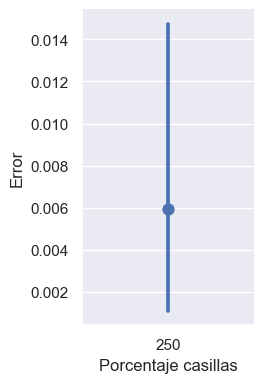

In [ ]:
sns.set_theme();
ax = sns.catplot(
    data=df_error_max_v_est, x="Porcenta_tama", y="Error_max",
    kind="point", height=4, aspect=.7, errorbar='pi'
);
ax.set(xlabel='Porcentaje casillas', ylabel='Error');

In [ ]:
# Base para poder hacer las gráficas de mínima cobertura e intervalos más largos
df_metr_boot_c_v_est=df_metr_boot_v_est.drop(columns="Cobertura").merge(df_can_cob_v_est[["Candidato","Cobertura"]], on=["Candidato"], how='left')
df_metr_boot_c_v_est

,Num_bootstrap,cuantil_025,cuantil_975,Longitud_intervalo,Estamacion_puntual,Porcentaje_real,Candidato,Error,Porcenta_tama,Cobertura
0,1,0.49480,0.53520,0.04040,0.514614,0.515125,JOAQUIN_DIAZ_MENA,0.000511,250,1.0
1,2,0.49999,0.53800,0.03801,0.519563,0.515125,JOAQUIN_DIAZ_MENA,0.004438,250,1.0
2,3,0.49120,0.52921,0.03801,0.510321,0.515125,JOAQUIN_DIAZ_MENA,0.004805,250,1.0
3,4,0.48879,0.52641,0.03762,0.507822,0.515125,JOAQUIN_DIAZ_MENA,0.007303,250,1.0
4,5,0.50160,0.54000,0.03840,0.520690,0.515125,JOAQUIN_DIAZ_MENA,0.005565,250,1.0
...,...,...,...,...,...,...,...,...,...,...
995,196,0.01640,0.02800,0.01160,0.022088,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000621,250,1.0
996,197,0.01560,0.02760,0.01200,0.021478,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000011,250,1.0
997,198,0.01639,0.02720,0.01081,0.021816,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000349,250,1.0
998,199,0.01600,0.02720,0.01120,0.021259,0.021467,VOTOS_NULOS_CAND_NO_REGIS,0.000208,250,1.0


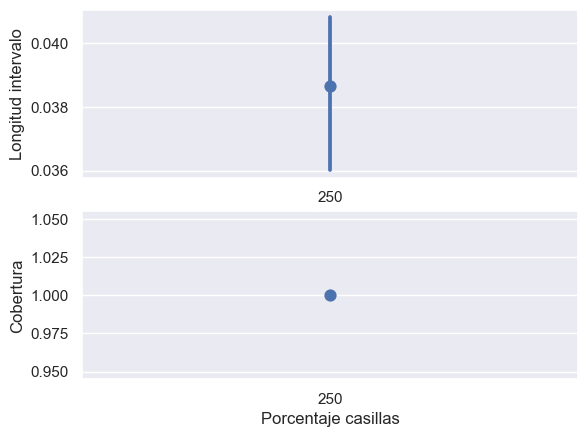

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi',ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_mas_largo_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');


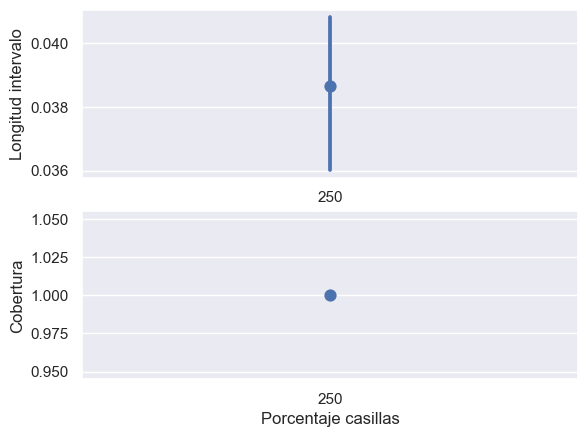

In [ ]:
facet_kws={'sharey': False, 'sharex': True}
fig, axx =plt.subplots(2,1)
ax_1=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est], x="Porcenta_tama", y="Longitud_intervalo", errorbar='pi', ax=axx[0]
);
ax_2=sns.pointplot(
    data=df_metr_boot_c_v_est[df_metr_boot_c_v_est["Candidato"]==candidato_cober_men_v_est].head(1), x="Porcenta_tama", y="Cobertura", ax=axx[1]
)
ax_1.set(xlabel='Porcentaje casillas', ylabel='Longitud intervalo');
ax_2.set(xlabel='Porcentaje casillas', ylabel='Cobertura');

In [ ]:
%lprun -f boot_votos_estratificado boot_votos_estratificado(df_act_yuc_i, num_boot=10, n_sample=250)

250


Timer unit: 1e-09 s

Total time: 7.29078 s
File: /var/folders/jr/f7xjgzh56h75snyd84nvhbdc0000gn/T/ipykernel_1890/2613430673.py
Function: boot_votos_estratificado at line 2

Line #      Hits         Time  Per Hit   % Time  Line Contents
     2                                           def boot_votos_estratificado(df_act_yuc_i, num_boot: int=1000, n_sample=None, frac=None):
     3                                           
     4                                               # Listas auxiliares para guardar los datos
     5         1       1000.0   1000.0      0.0      est_punt_list=[]
     6                                           
     7         1          0.0      0.0      0.0      inter_list=[]
     8                                           
     9                                               # Cuantas casillas hay por distrito en toda la base
    10         1    1015000.0    1e+06      0.0      array_frec_est=np.array(df_act_yuc_i["DISTRITO"].value_counts().sort_index())
    11